In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)

pandas: 3.0.3
matplotlib: 3.11.0
seaborn: 0.13.2


# Retail Sales Data - Exploratory Data Analysis (EDA)
## Project Objective
The objective of this project is to perform an exploratory data analysis of retail sales data to identify sales patterns, customer behaviour trends, product performance, and actionable business insights,

In [52]:
df = pd.read_excel("Retail_sales_dataset.xlsx")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [49]:
df = pd.read_excel("Retail_sales_dataset.xlsx")
print("First 5 Rows of the Dataset:")
display(df.head())
print("\nFirst 5 Columns of the Dataset:")
display(df.iloc[:, :5].head())

First 5 Rows of the Dataset:


,CustomerID,FirstName,LastName,Gender,BirthDate,City,JoinDate
0,C001,Michael,Davis,M,1996-09-11,Osborneport,2022-09-25
1,C002,Michael,Miller,M,1959-08-18,New Gabrielleport,2020-11-03
2,C003,Carol,Hays,F,2005-04-19,Port Allen,2024-02-12
3,C004,Joseph,Ward,M,1992-06-16,East Edgarborough,2024-09-09
4,C005,Jamie,Salinas,M,1992-06-18,Port Kimberly,2022-02-24



First 5 Columns of the Dataset:


,CustomerID,FirstName,LastName,Gender,BirthDate
0,C001,Michael,Davis,M,1996-09-11
1,C002,Michael,Miller,M,1959-08-18
2,C003,Carol,Hays,F,2005-04-19
3,C004,Joseph,Ward,M,1992-06-16
4,C005,Jamie,Salinas,M,1992-06-18


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   CustomerID  200 non-null    str           
 1   FirstName   200 non-null    str           
 2   LastName    200 non-null    str           
 3   Gender      200 non-null    str           
 4   BirthDate   200 non-null    datetime64[us]
 5   City        200 non-null    str           
 6   JoinDate    200 non-null    datetime64[us]
dtypes: datetime64[us](2), str(5)
memory usage: 16.7 KB


In [5]:
excel_file = pd.ExcelFile("Retail_sales_dataset.xlsx")
print(excel_file.sheet_names)

['Customers', 'Products', 'Stores', 'Transactions']


In [6]:
transactions = pd.read_excel("Retail_sales_dataset.xlsx", sheet_name="Transactions")
print(transactions.shape)

(5000, 8)


In [11]:
print("Transactions columns:")
print(transactions.columns.tolist())
print("\nSales columns:")
print(sales.columns.tolist())

Transactions columns:
['TransactionID', 'Date', 'CustomerID', 'ProductID', 'StoreID', 'Quantity', 'Discount', 'PaymentMethod']

Sales columns:
['TransactionID', 'Date', 'CustomerID', 'ProductID', 'StoreID', 'Quantity', 'Discount', 'PaymentMethod', 'ProductName', 'Category', 'SubCategory', 'UnitPrice', 'CostPrice']


In [12]:
products = pd.read_excel("Retail_sales_dataset.xlsx", sheet_name="Products")
print("Products shape:", products.shape)
print("\nProduct columns:")
print(products.columns.tolist())

Products shape: (50, 6)

Product columns:
['ProductID', 'ProductName', 'Category', 'SubCategory', 'UnitPrice', 'CostPrice']


In [13]:
customers = pd.read_excel("Retail_sales_dataset.xlsx", sheet_name="Customers")
print("Customers shape:", customers.shape)
print("\nCustomer columns:")
print(customers.columns.tolist())

Customers shape: (200, 7)

Customer columns:
['CustomerID', 'FirstName', 'LastName', 'Gender', 'BirthDate', 'City', 'JoinDate']


In [14]:
stores = pd.read_excel("Retail_sales_dataset.xlsx", sheet_name="Stores")
print("Stores shape:", stores.shape)
print("\nStore columns:")
print(stores.columns.tolist())

Stores shape: (5, 4)

Store columns:
['StoreID', 'StoreName', 'City', 'Region']


In [15]:
transactions.duplicated().sum()

np.int64(0)

In [16]:
print(transactions.dtypes)

TransactionID               str
Date             datetime64[us]
CustomerID                  str
ProductID                   str
StoreID                     str
Quantity                  int64
Discount                float64
PaymentMethod               str
dtype: object


In [17]:
sales = transactions.merge(
    products,
    left_on="ProductID",
    right_on="ProductID",
    how="left"
)
print("Sales data shape:", sales.shape)
print("\nSales columns:")
print(sales.columns.tolist())

Sales data shape: (5000, 13)

Sales columns:
['TransactionID', 'Date', 'CustomerID', 'ProductID', 'StoreID', 'Quantity', 'Discount', 'PaymentMethod', 'ProductName', 'Category', 'SubCategory', 'UnitPrice', 'CostPrice']


In [18]:
sales = sales.merge(
    customers,
    left_on="CustomerID",
    right_on="CustomerID",
    how="left"
)
print("Sales data shape:", sales.shape)
print("\nSales columns:")
print(sales.columns.tolist())

Sales data shape: (5000, 19)

Sales columns:
['TransactionID', 'Date', 'CustomerID', 'ProductID', 'StoreID', 'Quantity', 'Discount', 'PaymentMethod', 'ProductName', 'Category', 'SubCategory', 'UnitPrice', 'CostPrice', 'FirstName', 'LastName', 'Gender', 'BirthDate', 'City', 'JoinDate']


In [19]:
sales = sales.merge(
    stores,
    left_on="StoreID",
    right_on="StoreID",
    how="left"
)
print("Sales data shape:", sales.shape)
print("\nSales columns:")
print(sales.columns.tolist())

Sales data shape: (5000, 22)

Sales columns:
['TransactionID', 'Date', 'CustomerID', 'ProductID', 'StoreID', 'Quantity', 'Discount', 'PaymentMethod', 'ProductName', 'Category', 'SubCategory', 'UnitPrice', 'CostPrice', 'FirstName', 'LastName', 'Gender', 'BirthDate', 'City_x', 'JoinDate', 'StoreName', 'City_y', 'Region']


In [20]:
print("Missing values in combined sales data:")
print(sales.isnull().sum())

Missing values in combined sales data:
TransactionID    0
Date             0
CustomerID       0
ProductID        0
StoreID          0
Quantity         0
Discount         0
PaymentMethod    0
ProductName      0
Category         0
SubCategory      0
UnitPrice        0
CostPrice        0
FirstName        0
LastName         0
Gender           0
BirthDate        0
City_x           0
JoinDate         0
StoreName        0
City_y           0
Region           0
dtype: int64


In [21]:
print(sales.select_dtypes(include="number").columns.tolist())

['Quantity', 'Discount', 'UnitPrice', 'CostPrice']


In [22]:
stats = sales[["Quantity", "Discount", "UnitPrice", "CostPrice"]].describe()
stats

,Quantity,Discount,UnitPrice,CostPrice
count,5000.00000,5000.000000,5000.000000,5000.000000
mean,2.98980,0.075880,1036.606538,701.998512
std,1.40943,0.056497,589.316649,426.686344
min,1.00000,0.000000,25.570000,15.280000
25%,2.00000,0.050000,428.050000,258.720000
50%,3.00000,0.100000,1193.090000,794.800000
75%,4.00000,0.150000,1487.410000,1004.090000
max,5.00000,0.150000,1952.650000,1451.270000


In [23]:
sales[["Quantity", "Discount", "UnitPrice", "CostPrice"]].mode()

,Quantity,Discount,UnitPrice,CostPrice
0,2.0,0.15,1134.80,675.10
1,NaN,NaN,1878.47,1014.91
2,NaN,NaN,1952.65,1451.27


In [24]:
summary_stats = sales[["Quantity", "Discount", "UnitPrice", "CostPrice"]].agg(
    ["mean", "median", "std"]
)
summary_stats

,Quantity,Discount,UnitPrice,CostPrice
mean,2.98980,0.075880,1036.606538,701.998512
median,3.00000,0.100000,1193.090000,794.800000
std,1.40943,0.056497,589.316649,426.686344


### Descriptive Statistics 
The descriptive statisticcs show that the average quantity per transaction is approximately 3 units, with a median of 3 units, indicating a fairly consistent transaction quantity.
The average discount is approximately 7.6%, while the median discount is 10%. The most common discount is 15%, showing that several transactions received the same promotional discount.
Unit prices vary considerably, with a mean of approximately 1,036.61 and a median of approximately 1,193.09. Cost prices also show susbstantial variation, indicating differences in product pricing and cost structures across the product range.
Overall, the variation in unit and cost prices suggest that product-level analysis will be important for understanding revenue and profitability.

In [25]:
sales["NetSales"] = (
    sales["Quantity"] * sales["UnitPrice"] * (1 - sales["Discount"])
        )
print(sales[["Quantity", "UnitPrice", "Discount", "NetSales"]].head())

   Quantity  UnitPrice  Discount  NetSales
0         1    1342.75      0.10  1208.475
1         3      29.24      0.15    74.562
2         2     818.76      0.15  1391.892
3         5    1044.64      0.10  4700.880
4         3    1501.46      0.10  4053.942


In [26]:
monthly_sales = sales.groupby(
    sales["Date"].dt.to_period("M")
)["NetSales"].sum()
monthly_sales

Date
2023-09    380992.2780
2023-10    561231.1620
2023-11    584407.2790
2023-12    653301.1950
2024-01    584040.1460
2024-02    541610.5095
2024-03    553927.1820
2024-04    590578.4035
2024-05    565966.3105
2024-06    634753.7710
2024-07    555082.5825
2024-08    518784.3440
2024-09    589517.5645
2024-10    661780.3440
2024-11    567454.7275
2024-12    663271.3495
2025-01    628306.7690
2025-02    516524.2395
2025-03    585784.7300
2025-04    708233.4800
2025-05    632784.8700
2025-06    679817.8090
2025-07    610693.2775
2025-08    587098.4135
2025-09    145960.4105
Freq: M, Name: NetSales, dtype: float64

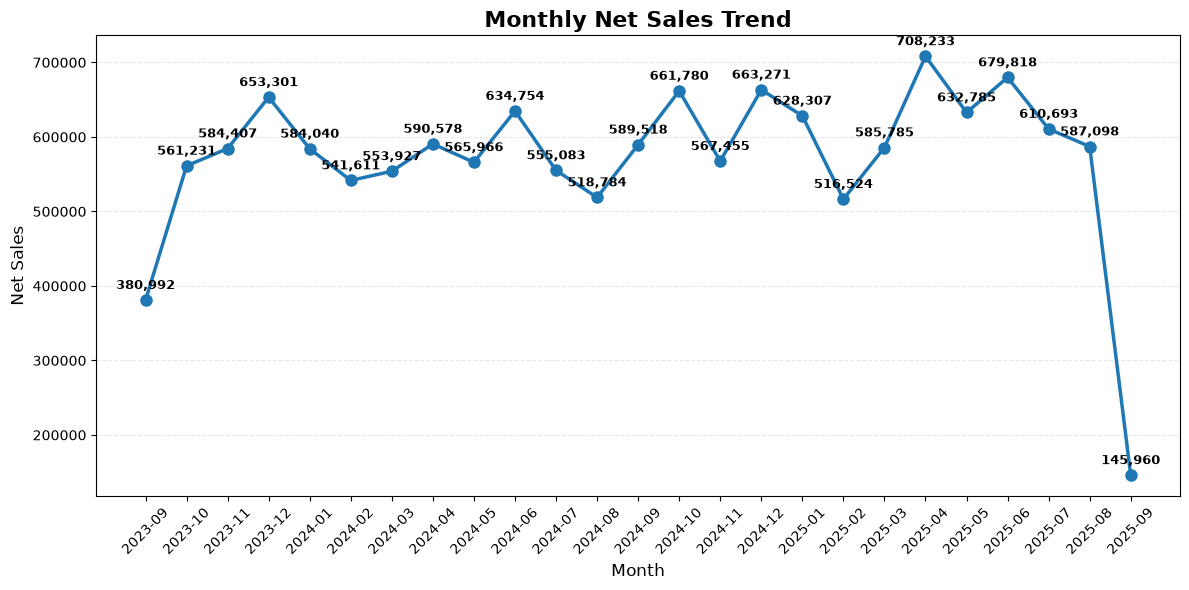

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    linewidth=2.5,
    markersize=8
)

plt.title(
    "Monthly Net Sales Trend",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Net Sales", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Display the sales total above each point
for x, y in zip(monthly_sales.index.astype(str), monthly_sales.values):
    plt.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Monthly Sales Trend 
The monthly net sales show noticeable fluctuations throughout the period rather than a consistent upward or downward trend. Sales increased substantially after the first recorded month and generally remained within a relatetively high range. although several peaks and dips are visible.
The fluctuations suggest that sales performance may be influenced by factors such as seasonal demand, promotions, or changes in customer purchasing behaviour. The higher sales levels observed toward the later part of the periods of stronger revenue performance that may warrant further investigation.

In [28]:
quarterly_sales = sales.groupby(
    sales["Date"].dt.to_period("Q")
)["NetSales"].sum()
quarterly_sales

Date
2023Q3    3.809923e+05
2023Q4    1.798940e+06
2024Q1    1.679578e+06
2024Q2    1.791298e+06
2024Q3    1.663384e+06
2024Q4    1.892506e+06
2025Q1    1.730616e+06
2025Q2    2.020836e+06
2025Q3    1.343752e+06
Freq: Q-DEC, Name: NetSales, dtype: float64

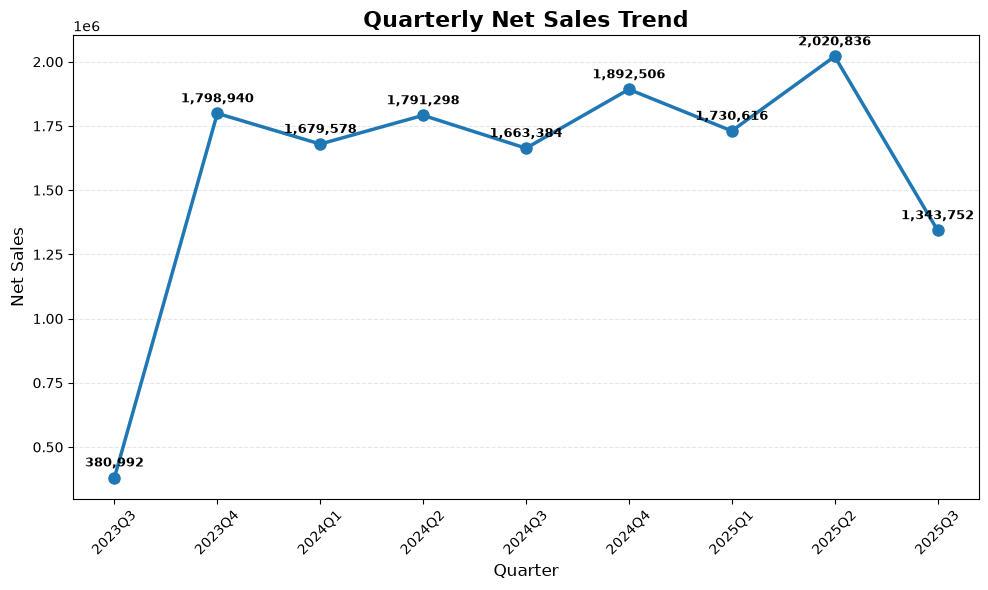

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker="o",
    linewidth=2.5,
    markersize=8
)

plt.title(
    "Quarterly Net Sales Trend",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Net Sales", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Add values to each point
for x, y in zip(quarterly_sales.index.astype(str), quarterly_sales.values):
    plt.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Quarterly Sales Trend 
The quarterly net sales trend shows an overall higher sales level after the initial quarter, although sales fluctuate from quarter to quarter.
Sales reached their highest level in Q2 2025, indicating a particularly strong sales period, However, sales declined noticeably in Q3 2025, The recurring increases and decreases suggest that sales performance may be affected by seasonal demand, promotions,  product mix, or other business factors.
The strong performance in Q2 2025 should be investigated further to identify the products, customer segments, and stores that contributed most to the increase.

In [30]:
print(sales["Gender"].value_counts())

Gender
M    2810
F    2190
Name: count, dtype: int64


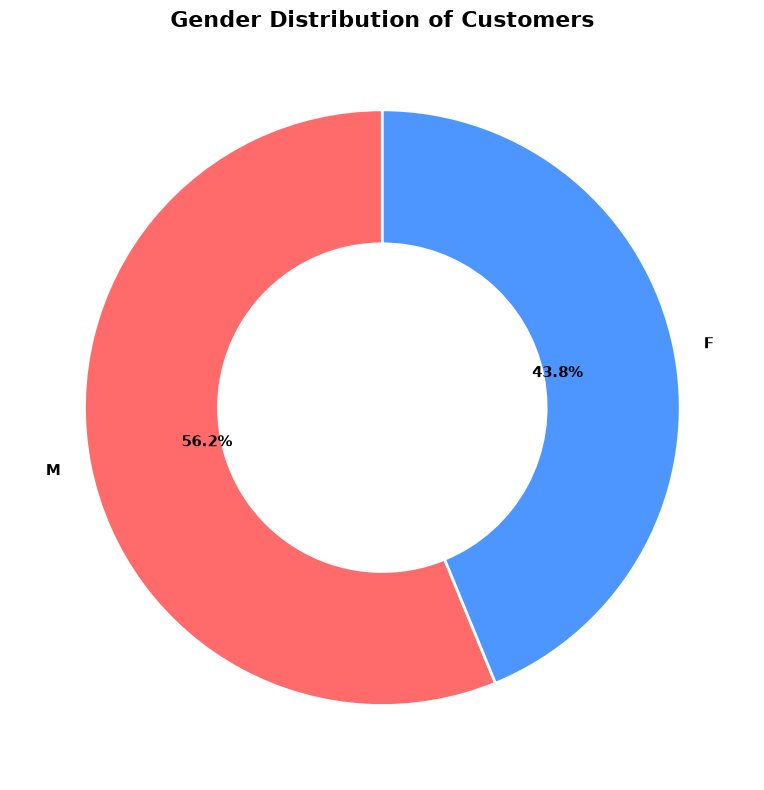

In [31]:
gender_counts = sales["Gender"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#FF6B6B", "#4D96FF"],
    wedgeprops={
        "width": 0.45,
        "edgecolor": "white",
        "linewidth": 2
    },
    textprops={
        "fontsize": 11,
        "fontweight": "bold"
    }
)

plt.title(
    "Gender Distribution of Customers",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Gender Breakdown 
The gender breakdown shows that male customers account for  2,810 transactions, while female customers account  for 2,190 transactions. This means male customers represent approximately 56.2% of transactions, compared with 43.8% for female customers.
The relatively balanced distribution between the two groups suggests that the business serves both male and female customers respectively. However, the slightly higher transaction activity among male customers indicate an opportunity to investigate differences in purchasing preferences, product choices, and promotional responses between the two groups.
This insight can help the business develop more targeted marketing strategies while avoiding an overly narrow focus on either gender.

In [32]:
# Convert date columns to datetime
sales["Date"] = pd.to_datetime(sales["Date"])
sales["BirthDate"] = pd.to_datetime(sales["BirthDate"])

# Calculate customer age at the time of each transaction
sales["Age"] = (
    sales["Date"].dt.year - sales["BirthDate"].dt.year
    - (
        (sales["Date"].dt.month < sales["BirthDate"].dt.month)
        |
        (
            (sales["Date"].dt.month == sales["BirthDate"].dt.month)
            & (sales["Date"].dt.day < sales["BirthDate"].dt.day)
        )
    )
)

# Create age groups
sales["Age Group"] = pd.cut(
    sales["Age"],
    bins=[0, 17, 24, 34, 44, 54, 64, 100],
    labels=[
        "Under 18",
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "64+"
    ]
)

# Count transactions by age group
age_counts = sales["Age Group"].value_counts().sort_index()

print(age_counts)

Age Group
Under 18      56
18-24        717
25-34        867
35-44        891
45-54        952
55-64       1153
64+          364
Name: count, dtype: int64


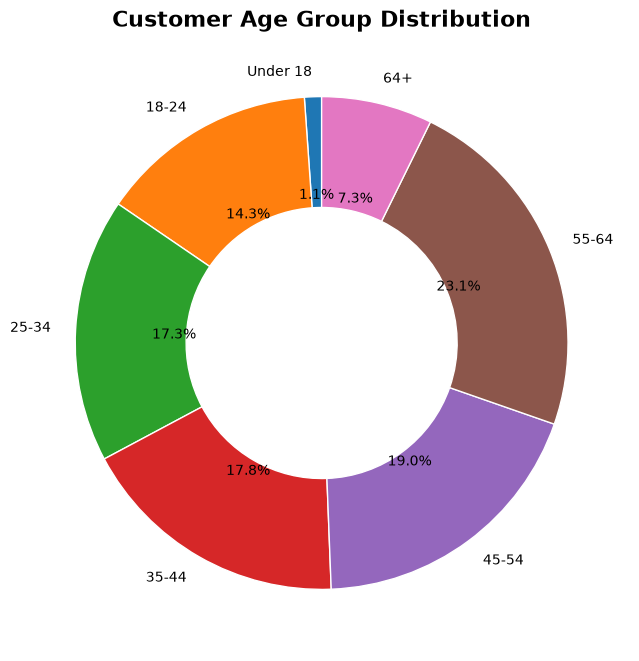

In [33]:
plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white')
)

plt.title('Customer Age Group Distribution', fontsize=16, fontweight='bold')

plt.show()

### Age Group Distribution 
The age-group distribution shows that customers are concentrated mainly within the adult age categories, with some age groups accounting for a larger share of transactions than others.
The differences in transaction activity across age groups suggest that customer purchasing behaviour varies by age. This information can help the business identify its most active customer segments and develop more targeted marketing campaigns, product recommendations, and promotional offers.
Understanding the dominant age groups can also support better customer segmentation and help the business tailor its products and communication strategies to the customers most likely to purchase.

In [48]:
product_quantity = sales.groupby("ProductName")["Quantity"].sum()
print(sales[["ProductName", "Quantity"]].head(10).to_string())
sales[["ProductName", "Quantity"]].head()

           ProductName  Quantity
0         Add Clothing         1
1     National Watches         3
2  Audience Television         2
3       Maybe Footwear         5
4          New Watches         3
5          New Watches         5
6            Us Snacks         2
7       Knowledge Bags         3
8         Chair Laptop         3
9            Set Dairy         1


,ProductName,Quantity
0,Add Clothing,1
1,National Watches,3
2,Audience Television,2
3,Maybe Footwear,5
4,New Watches,3


In [35]:
top_10_products = product_quantity.sort_values(ascending=False).head(10)
print(top_10_products)

ProductName
Road Clothing          346
How Vegetables         343
Audience Television    341
Everything Laptop      338
Book Television        337
And Footwear           336
World Watches          335
Nor Bags               332
Set Dairy              330
Firm Dairy             327
Name: Quantity, dtype: int64


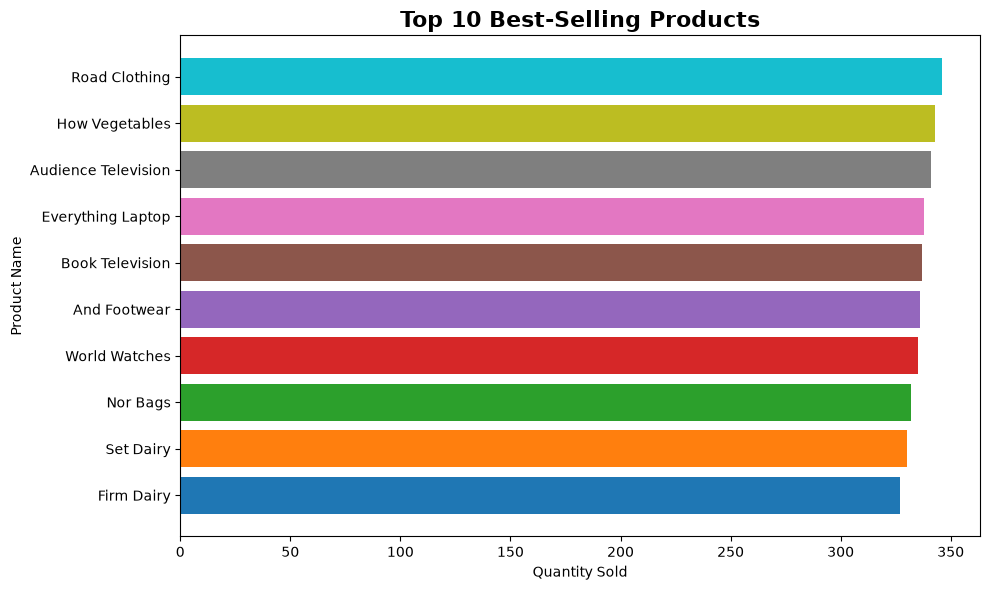

In [36]:
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(range(len(top_10_products)))

plt.barh(
    top_10_products.index[::-1],
    top_10_products.values[::-1],
    color=colors
)

plt.title('Top 10 Best-Selling Products', fontsize=16, fontweight='bold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

### Top 10 Best Selling Products 
The top-selling product by quantity was Road Clothing, with 346 units sold,followed by the How Vegetables with 343 units and Audience Television with 341 units.
The remaining  products in the top 10 also recorded relatively similar sales volumes, ranging from 327 to 338 units. This relatively narrow range suggests that product demand is distributed  across  several products rather than being concentrated in only one or two items.
The business should ensure that high-volume products such as Road Clothing and How Vegetables remain adequately stocked. Further analysisof revenue and profitability is also recommended to determine whether the products with the highest sales volume are also the most financially valuable.

In [37]:
category_revenue = sales.groupby("Category")["NetSales"].sum()
print(category_revenue)

Category
Electronics    6.316917e+06
Fashion        6.232280e+06
Groceries      1.752706e+06
Name: NetSales, dtype: float64


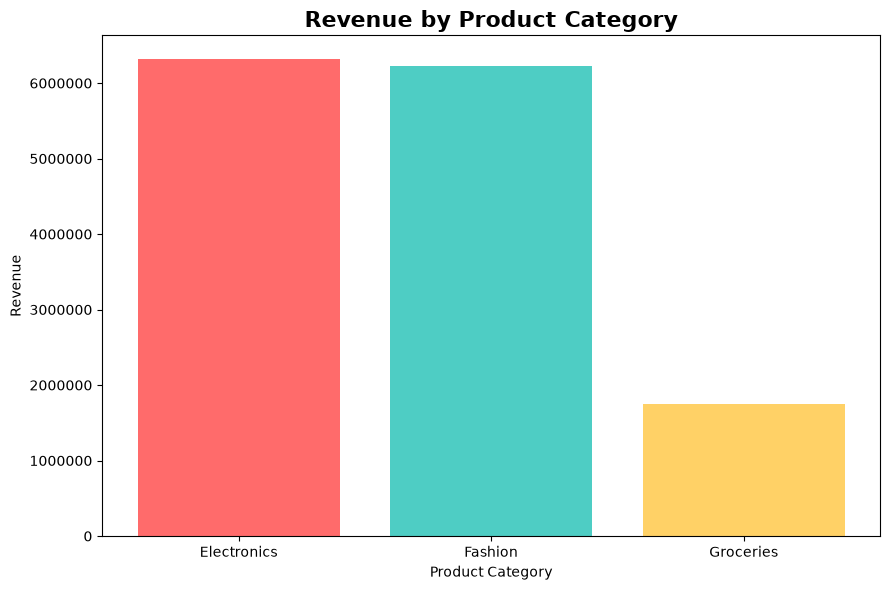

In [38]:
plt.figure(figsize=(9, 6))

colors = ['#FF6B6B', '#4ECDC4', '#FFD166']

plt.bar(
    category_revenue.index,
    category_revenue.values,
    color=colors
)

plt.title('Revenue by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

### Revenue by Product Category 
The revenue distribution shows that sales performance varies across product categories, with some categories contributing more to total net sales than others.
The differences in category-level revenue indicates that product mix plays an important role in overall business performance. Categories generating higher revenue should be monitored closely to maintain stock levels and avoid missed sales opportunities.
Lower_revenue categories should also be investigated to determine whether their performance is related to lower demand, pricing, product availability, or promotional activity. This can help the business make better decisions about inventory, pricing, and marketing strategies.

In [39]:
numeric_data = sales.select_dtypes(include='number')
numeric_data.columns

Index(['Quantity', 'Discount', 'UnitPrice', 'CostPrice', 'NetSales', 'Age'], dtype='str')

In [40]:
correlation_matrix = numeric_data.corr()
correlation_matrix

,Quantity,Discount,UnitPrice,CostPrice,NetSales,Age
Quantity,1.000000,-0.002085,-0.005072,-0.006183,0.596828,0.006396
Discount,-0.002085,1.000000,0.002196,0.000483,-0.078230,-0.013875
UnitPrice,-0.005072,0.002196,1.000000,0.967710,0.716818,-0.015420
CostPrice,-0.006183,0.000483,0.967710,1.000000,0.692718,-0.010081
NetSales,0.596828,-0.078230,0.716818,0.692718,1.000000,-0.009477
Age,0.006396,-0.013875,-0.015420,-0.010081,-0.009477,1.000000


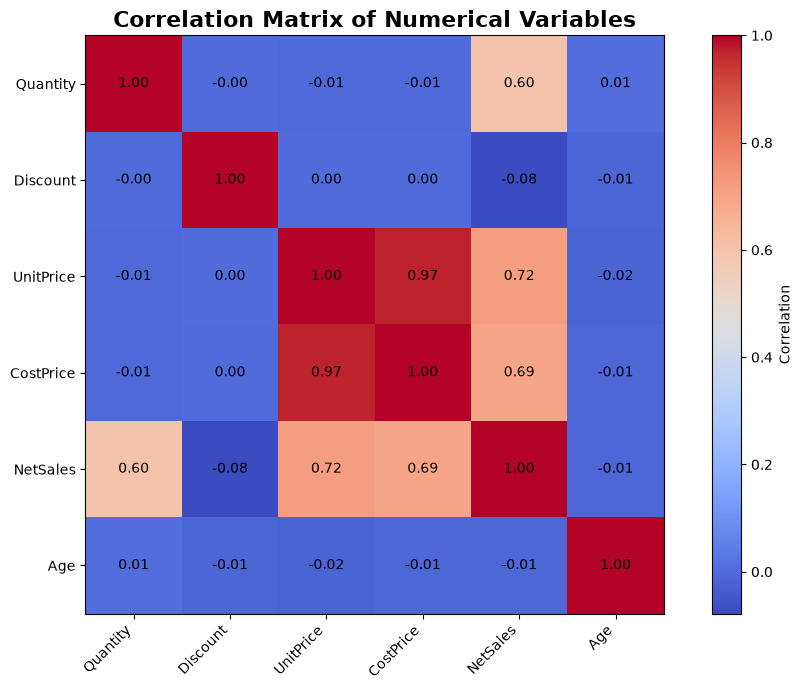

In [41]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Display correlation values inside each cell
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center',
            color='black',
            fontsize=10
        )

plt.title(
    'Correlation Matrix of Numerical Variables',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Correlation Matrix 
The correlation matrix shows the strength and direction of relationships between the numerical variables in the dataset. The correlation heatmap shows that UnitPrice and CostPrice have a very strong positive correlation (0.97). NetSales also has a strong positive relationship with UnitPrice (0.72) and CostPrice (0.69), while Quantity has a moderate positive correlation with NetSales (0.60). Discount and Age show very weak correlations with most of the other numerical variables.
NetSales has a strong positive correlation with UnitPrice, indicating that transactions involving higher-priced products generally generate higher net sales. NetSales also has a positive relationship with Quantity, meaning that selling more units tends to increase sales revenue.
Discount has a negative relationship with NetSales, suggesting that higher discounts may reduce the amount of net sales generated per transaction. Age shows relatively weak correlations with most of the numerical variables, indicating that customer age does not have a strong direct linear relationship with transaction quantity, pricing, discount, or net sales.
Overall, the correlation analysis highlights UnitPrice, Quantity, and Discount as variables that are particularly relevant when examining sales performance.

In [42]:
discount_profit = sales['NetSales'] - sales['CostPrice']

In [43]:
sales["TotalCost"] = sales["Quantity"] * sales["CostPrice"]
sales["Profit"] = sales["NetSales"] - sales["TotalCost"] 
print(sales[["NetSales", "TotalCost", "Profit"]].head())

   NetSales  TotalCost   Profit
0  1208.475     797.94  410.535
1    74.562      45.84   28.722
2  1391.892    1055.24  336.652
3  4700.880    3875.35  825.530
4  4053.942    3503.19  550.752


In [44]:
discount_profit = (
    sales.groupby("Discount")["Profit"]
    .mean()
    .sort_index()
)
print(discount_profit)

Discount
0.00    995.896951
0.05    837.870907
0.10    704.380874
0.15    534.587273
Name: Profit, dtype: float64


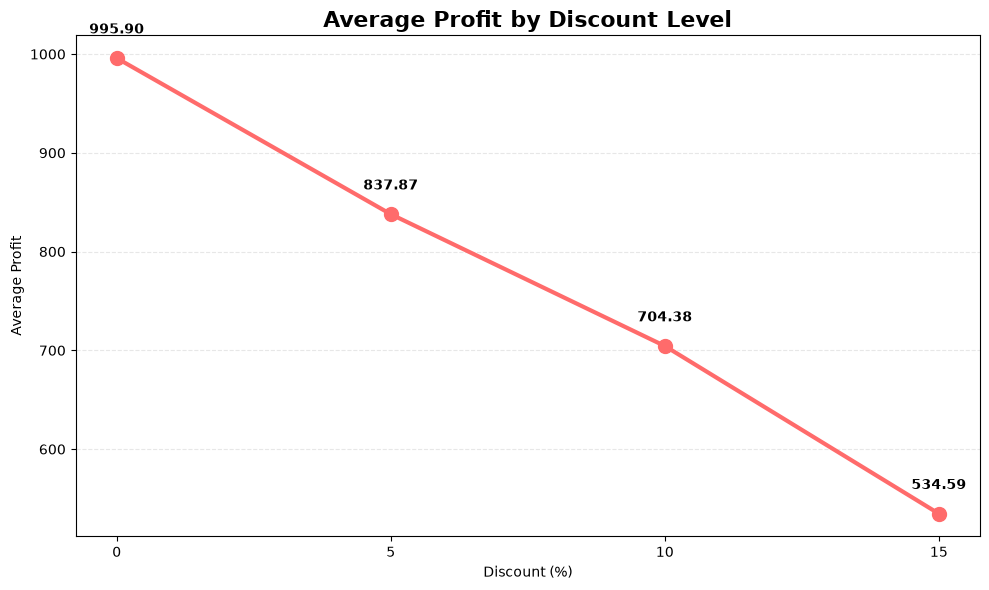

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_profit.index * 100,
    discount_profit.values,
    marker='o',
    markersize=10,
    linewidth=3,
    color='#FF6B6B'
)

# Add value labels
for x, y in zip(discount_profit.index * 100, discount_profit.values):
    plt.text(
        x,
        y + 25,
        f'{y:,.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Average Profit by Discount Level',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Discount (%)')
plt.ylabel('Average Profit')

plt.xticks([0, 5, 10, 15])

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Average Profit by Discount Level 
The chart analysis shows that average profit decreases consistently as the discount level increases. Average profit level decline from 995.90 at 0% discount to 837.87 at 5%, 704.38 at 10%, and 534.59 at 15%. This suggests that higher discounts are associated with lower average profit per transaction, highlighting the potential impact of discounting on profitability. Transactions with no discount generated the highest average profit of approximately 995.90, while transaction with a 15% discount generated the lowest average profit of approximately 544.59.
The business should therefore evaluate discount levels carefully and avoid applying high discounts broadly. Instead, discounts could be targeted toward specific products, customer segments, or periods where they are most likely to increase sales enough to justify the reduction in profit.

## Conclusion and Business Recommendations

The exploratory data analysis provided useful insights into sales performance, customer behaviour, product demand, and profitability. The analysis showed fluctuations in monthly and quarterly net sales, a relatively balanced customer gender distribution, differences in purchasing activity across age groups, and variation in product and category performance.

The product analysis showed that several products recorded high sales volumes, with Road Clothing being the highest-selling product by quantity. The category analysis also showed that revenue contribution varies across product categories, highlighting the importance of monitoring product mix and category performance.

The profitability analysis revealed an important relationship between discounts and profit. Average profit decreased as the discount level increased, falling from approximately 995.90 at 0% discount to approximately 544.59 at 15% discount. This suggests that discounting can have a substantial effect on profitability.

### Actionable Business Recommendations

1. **Use targeted rather than broad discounts:**  
   Since higher discount levels were associated with lower average profit, the business should avoid applying large discounts across all products. Discounts should instead be targeted at specific products, customer segments, or periods where they are most likely to generate additional sales.

2. **Prioritize high-performing products and categories:**  
   Products with consistently high sales volumes should receive careful inventory monitoring to reduce the risk of stockouts. Higher-revenue categories should also be prioritized when planning inventory and marketing activities.

3. **Investigate strong and weak sales periods:**  
   The noticeable fluctuations in monthly and quarterly sales suggest that factors such as seasonality, promotions, product mix, and customer behaviour may influence performance. The business should investigate periods of unusually high or low sales to identify patterns that can improve future sales planning.

4. **Develop customer-specific marketing strategies:**  
   Differences in purchasing activity across gender and age groups suggest that customer demographics can support more targeted marketing. The business should analyse product preferences and purchasing behaviour within these groups before designing promotions and campaigns.

5. **Monitor profitability alongside sales volume:**  
   High sales volume does not necessarily mean high profitability. The business should evaluate products using both quantity sold and profit generated so that inventory and promotional decisions focus on financially valuable products.